# Experiences sur les résultats obtenues avec notre modèle d'ordonnancement

In [89]:
%load_ext autoreload
%autoreload 2

import gurobipy as gp
from gurobipy import GRB

from matplotlib import pyplot as plt

from first_model import Instance, Solution, Model
from utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## I. Visualisation du graphe de précédence des opérations et sous-opérations pour chaque Job du fichier suivant: 
**data_many_constraints_precedence.test**

Ce fichier contient **2 jobs**, chacun avec **5 opérations**, une opération peut contenir au maximum **10 sous-opérations**

In [156]:
res_many_constraints = read_file("../data/data_many_constraints_precedence.test")
instance_many_constraints = Instance(res_many_constraints)

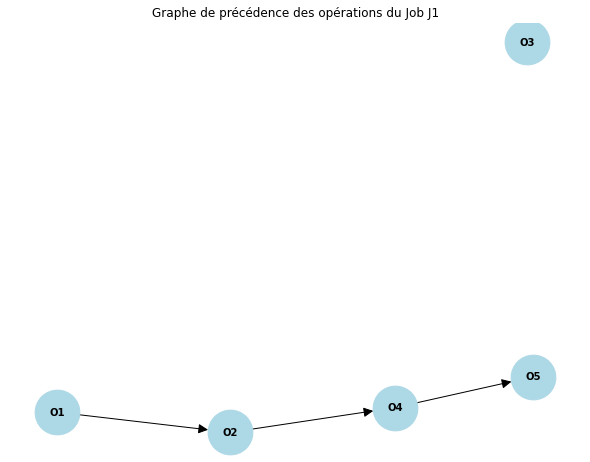

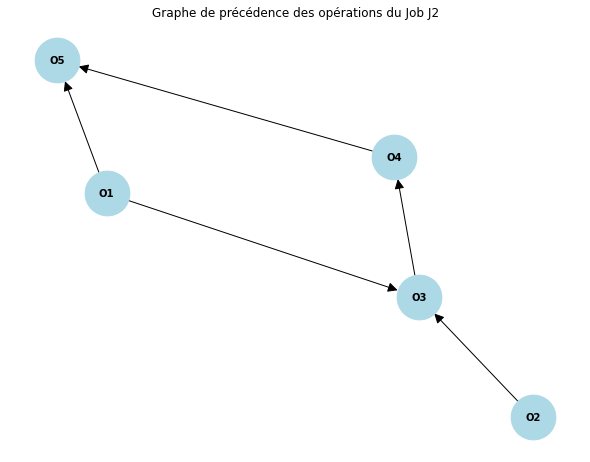

In [157]:
plot_precedence_graph(instance_many_constraints)

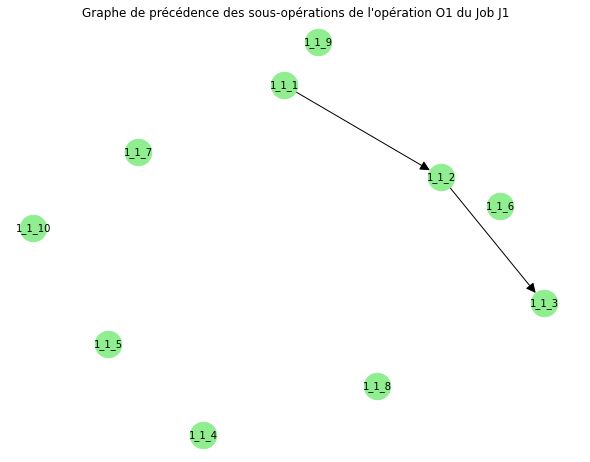

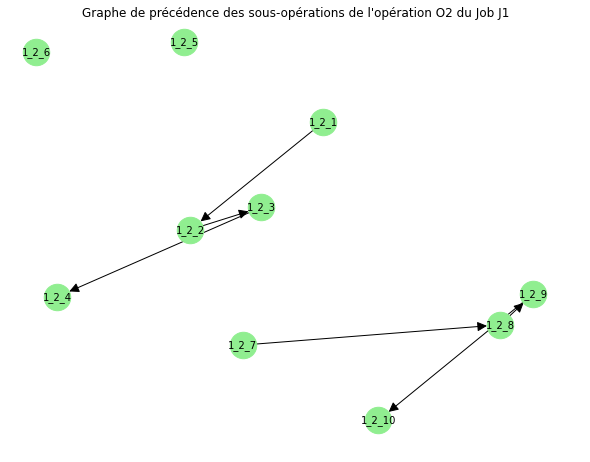

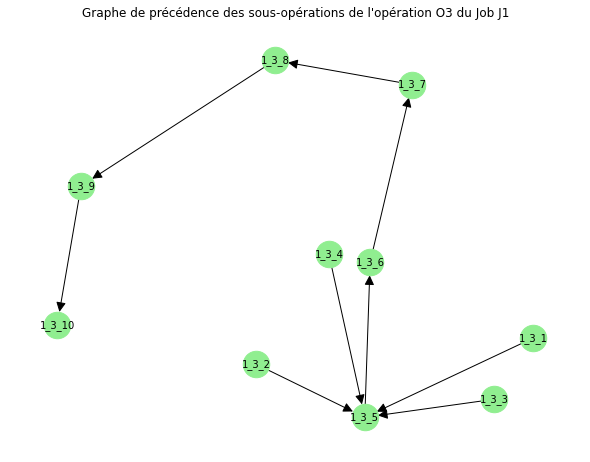

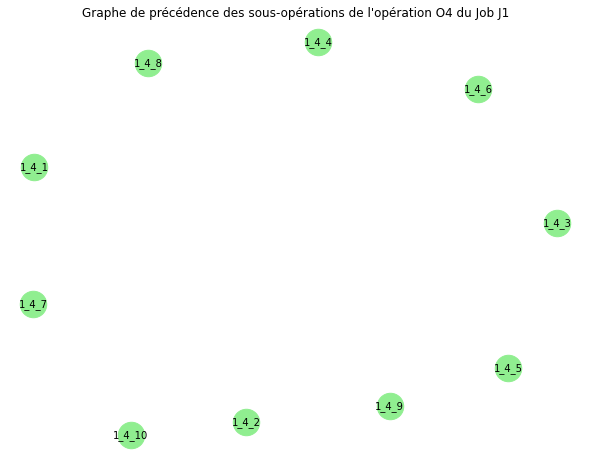

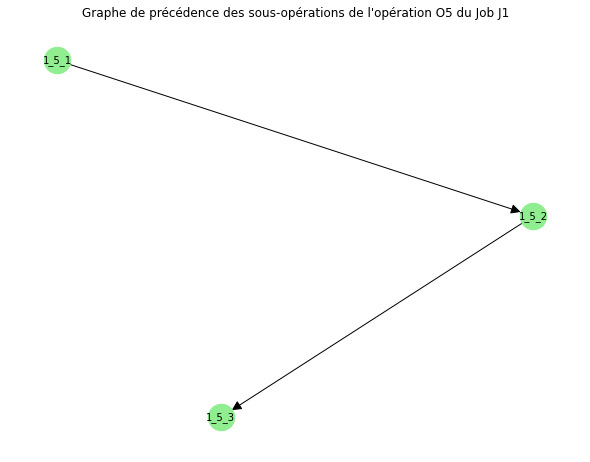

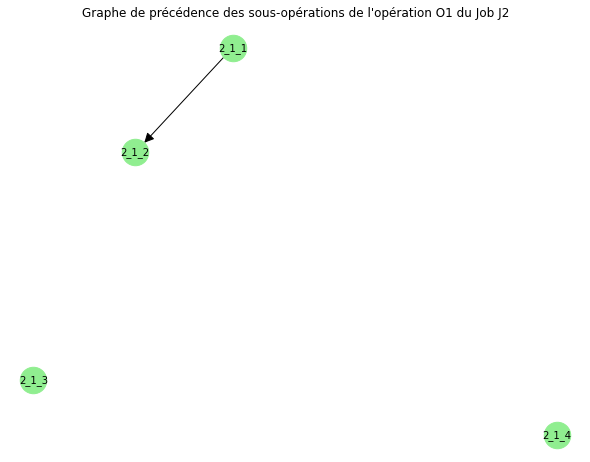

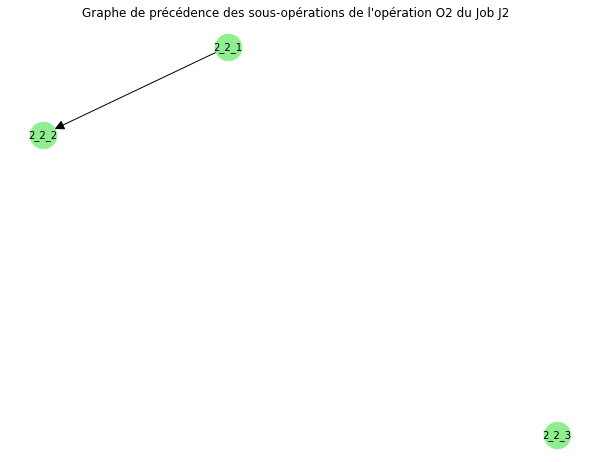

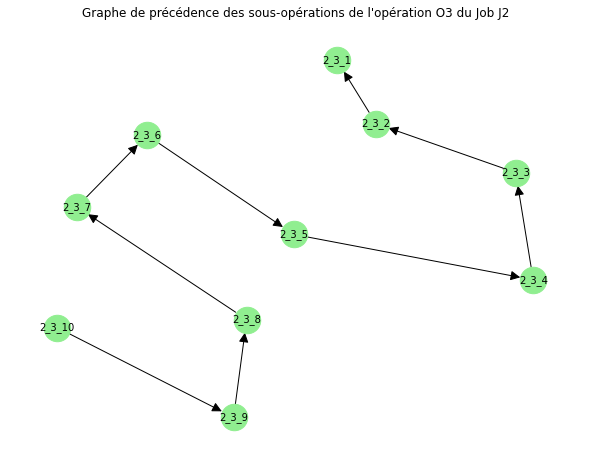

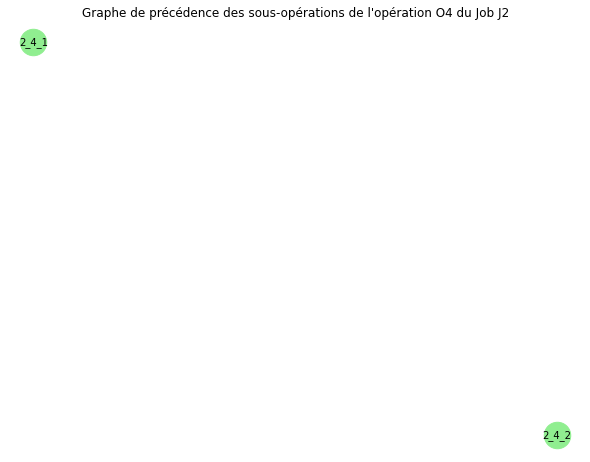

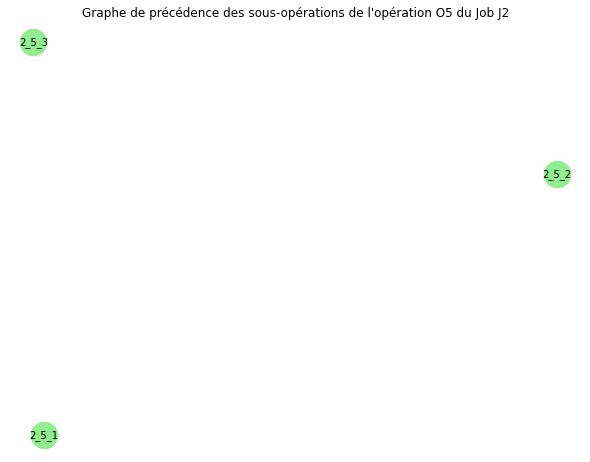

In [158]:
plot_precedence_graph_sub_operations(instance_many_constraints)

## II. Instance plus simple pour tester résultats

### 1) Visualisation des graphes de précédence

In [41]:
res = read_file("../data/data_temp.test")
instance = Instance(res)
print(instance)

-------------------------------------
Start of Instance:
-------------------------------------
Number of jobs: 2
Number of professions: 3
Number of sub-operations per profession: [2. 4. 1.]
Max number of operations per Jobs: 2
Max number of sub-operations per operation: 3
Total number of sub-operations: 7
Total number of workers: 3
Sub-operation to profession mapping:
{0: 0, 1: 0, 2: 1, 3: 1, 4: 1, 5: 1, 6: 2}
Worker levels: shape=(3, 3)
 [[1. 2. 1.]
 [4. 3. 2.]
 [1. 2. 1.]]
Job difficulties: shape= (2,)
[2. 2.]
Sub-operation difficulties: shape= (7,)
[1 1 3 3 2 2 2]
Sub-operation processing times: shape= (7, 3)
[[ 3.  4.  2.]
 [15. 15. -1.]
 [ 5.  8.  2.]
 [ 4.  6.  2.]
 [ 5. 10.  2.]
 [ 4. 11.  2.]
 [10. 20.  2.]]
Jobs structure: len= 2
Job 0 : 
	O_0 : 0 2 6 
	O_1 : 2 
Job 1 : 
	O_0 : 3 1 
	O_1 : 6 4 4 

Precedence constraints: shape= (2, 2, 2)
[[[0. 1.]
  [0. 0.]]

 [[0. 0.]
  [1. 0.]]]
Sub-operation precedence constraints: shape= (2, 2, 3, 3)
[[[[0. 1. 0.]
   [0. 0. 1.]
   [0. 0. 0

### 1a) Précédence entre les opérations d'un même job

In [42]:
plot_precedence_graph(instance)

### 1b) Précédence entre les sous-opérations d'une même opération d'un job

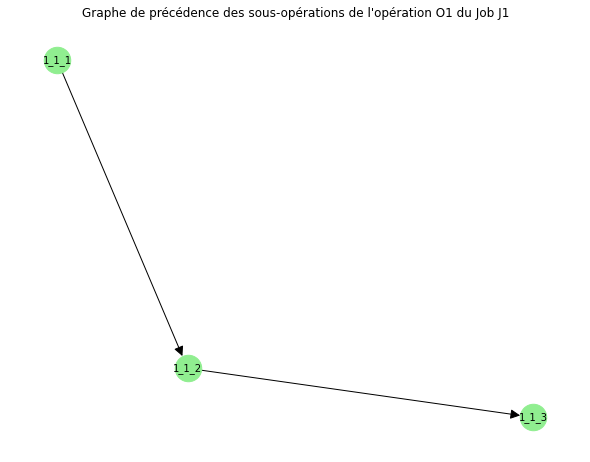

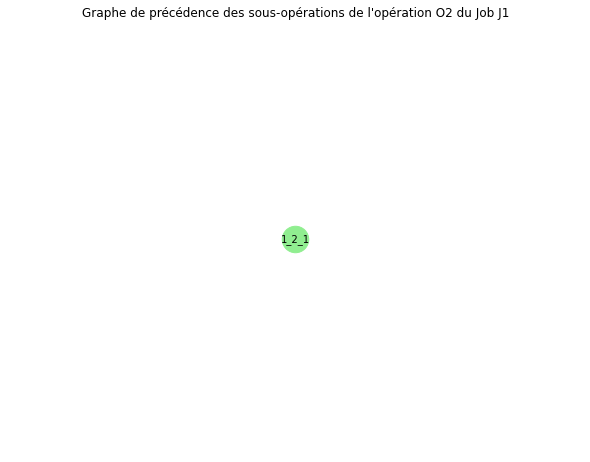

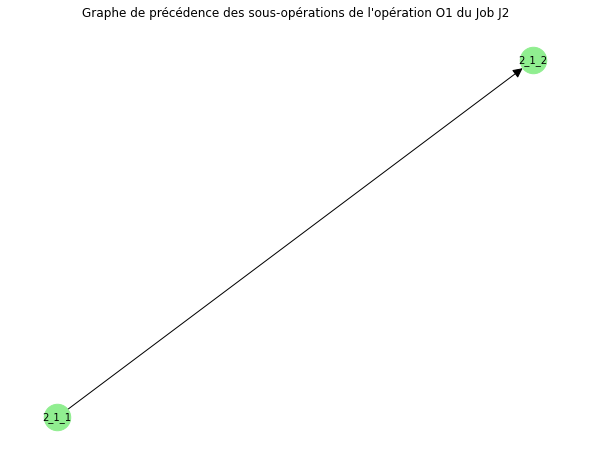

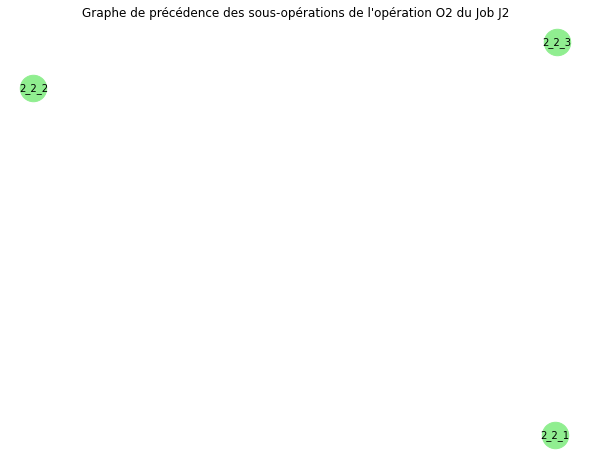

In [162]:
plot_precedence_graph_sub_operations(instance)

### 2) Résolution par la programmation linéaire avec Gurobi

# Min makespan seulement

In [176]:
model = Model(instance)
s = model.solve(objective="makespan",weight=[0.5, 0.5], priority=[0, 0], verbose=False)

Optimal solution found with objective value: 55.99999998831546


### 3) Visualisation du diagramme de Gantt

PS : Dans le data Frame de sortie de la fonction gantt_chart, j'ai ajouté + $0.1$ à chaque start pour pouvoir espacer les différentes tâches sur le diagramme de Gantt et éviter que les tâches soient collées les unes aux autres.

#### 3.1) Visualisation par sous-opération

In [181]:
gantt_chart(s, instance, color=0, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

,Task,Start,Finish,Sub_operation,Operation,Job,mode
0,w1,3.1,5.0,"(2,2,3)","(2,2)",J2,collaboratively
1,w1,20.1,22.0,"(2,2,2)","(2,2)",J2,collaboratively
2,w2,0.1,3.0,"(1,1,1)","(1,1)",J1,alone
3,w2,3.1,5.0,"(2,2,3)","(2,2)",J2,collaboratively
4,w2,5.1,10.0,"(1,1,2)","(1,1)",J1,alone
5,w2,10.1,20.0,"(2,2,1)","(2,2)",J2,alone
6,w2,20.1,22.0,"(2,2,2)","(2,2)",J2,collaboratively
7,w2,22.1,32.0,"(1,1,3)","(1,1)",J1,alone
8,w2,32.1,36.0,"(2,1,1)","(2,1)",J2,alone
9,w2,36.1,41.0,"(1,2,1)","(1,2)",J1,alone


#### 3.2) Visualisation par opération

In [182]:
df = gantt_chart(s, instance, color=1, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

#### 3.3) Visualisation par job

In [183]:
df = gantt_chart(s, instance, color=2, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

#### 3.4) Visualisationn par mode d'éxécution (seul, en apprentissage ou en collaboration)

In [184]:
df = gantt_chart(s, instance, color=3, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

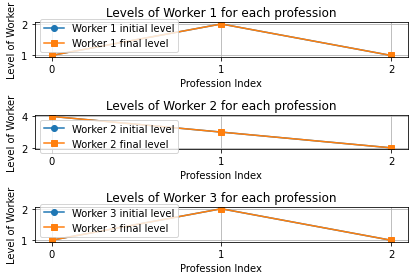

In [185]:
plot_levels_workers(s, instance)

# Max skill seulement

In [186]:
s = model.solve(objective="skill",weight=[0.5, 0.5], priority=[0, 0], verbose=False)

Optimal solution found with objective value: 19.0


In [187]:
gantt_chart(s, instance, color=0, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

,Task,Start,Finish,Sub_operation,Operation,Job,mode
0,w1,3.1,11.0,"(1,1,2)","(1,1)",J1,learning
1,w1,31.1,33.0,"(2,2,3)","(2,2)",J2,collaboratively
2,w1,33.1,35.0,"(2,2,2)","(2,2)",J2,collaboratively
3,w1,35.1,55.0,"(2,2,1)","(2,2)",J2,learning
4,w2,0.1,3.0,"(1,1,1)","(1,1)",J1,alone
5,w2,3.1,11.0,"(1,1,2)","(1,1)",J1,learning
6,w2,11.1,31.0,"(1,1,3)","(1,1)",J1,learning
7,w2,31.1,33.0,"(2,2,3)","(2,2)",J2,collaboratively
8,w2,33.1,35.0,"(2,2,2)","(2,2)",J2,collaboratively
9,w2,35.1,55.0,"(2,2,1)","(2,2)",J2,learning


In [188]:
df = gantt_chart(s, instance, color=1, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

In [189]:
df = gantt_chart(s, instance, color=2, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

In [190]:
df = gantt_chart(s, instance, color=3, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

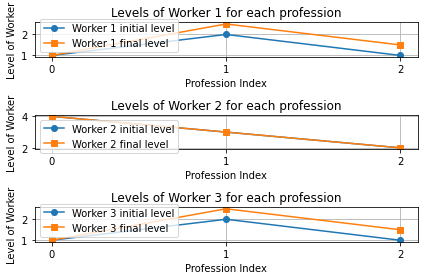

In [191]:
plot_levels_workers(s, instance)

# Min Makespan puis max skill (lexicographic)

In [192]:
s = model.solve(objective="lexicographic",weight=[0.5, 0.5], priority=[1, 0], verbose=False)

Optimal solution found with objective value: 56.00560025319356


In [193]:
gantt_chart(s, instance, color=0, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

,Task,Start,Finish,Sub_operation,Operation,Job,mode
0,w1,10.1,12.0,"(2,2,2)","(2,2)",J2,collaboratively
1,w2,0.1,2.0,"(2,2,3)","(2,2)",J2,collaboratively
2,w2,2.1,5.0,"(1,1,1)","(1,1)",J1,alone
3,w2,5.1,10.0,"(1,1,2)","(1,1)",J1,alone
4,w2,10.1,12.0,"(2,2,2)","(2,2)",J2,collaboratively
5,w2,12.1,22.0,"(2,2,1)","(2,2)",J2,alone
6,w2,22.1,32.0,"(1,1,3)","(1,1)",J1,alone
7,w2,32.1,36.0,"(2,1,1)","(2,1)",J2,alone
8,w2,36.1,51.0,"(2,1,2)","(2,1)",J2,alone
9,w2,51.1,56.0,"(1,2,1)","(1,2)",J1,alone


In [194]:
df = gantt_chart(s, instance, color=1, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

In [195]:
df = gantt_chart(s, instance, color=2, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

In [196]:
df = gantt_chart(s, instance, color=3, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

# Max skill, puis Min Makespan (lexicographic)

In [197]:
s = model.solve(objective="lexicographic",weight=[0.5, 0.5], priority=[0, 1], verbose=False)

Optimal solution found with objective value: 78.99999999199957


In [198]:
gantt_chart(s, instance, color=0, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

,Task,Start,Finish,Sub_operation,Operation,Job,mode
0,w1,2.1,22.0,"(2,2,1)","(2,2)",J2,learning
1,w2,0.1,2.0,"(2,2,3)","(2,2)",J2,collaboratively
2,w2,2.1,22.0,"(2,2,1)","(2,2)",J2,learning
3,w2,22.1,24.0,"(2,2,2)","(2,2)",J2,collaboratively
4,w2,24.1,32.0,"(1,1,2)","(1,1)",J1,learning
5,w2,32.1,36.0,"(2,1,1)","(2,1)",J2,alone
6,w2,36.1,56.0,"(1,1,3)","(1,1)",J1,learning
7,w2,56.1,64.0,"(1,2,1)","(1,2)",J1,learning
8,w2,64.1,79.0,"(2,1,2)","(2,1)",J2,alone
9,w3,0.1,2.0,"(2,2,3)","(2,2)",J2,collaboratively


In [199]:
df = gantt_chart(s, instance, color=1, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

In [200]:
df = gantt_chart(s, instance, color=2, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

In [201]:
df = gantt_chart(s, instance, color=3, render="notebook", save_path="../results/gantt_chart_instance_temp.html")

# ##Test des variables permettant de savoir quelle tache, le worker k a assisté un apprenti

In [45]:
res = read_file("../data/data_temp.test")
instance = Instance(res)

In [46]:
model = Model(instance)
s = model.solve(objective="lexicographic", weight=[0.5, 0.5], priority=[0, 1], verbose=True)
   

AssertionError: weight doit être une liste de trois éléments

In [9]:
gantt_chart(s, instance, color=3, render="notebook")
plot_levels_workers(s, instance, verbose=True)

NameError: name 's' is not defined

In [10]:
gantt_chart(s, instance, color=0, render="notebook")

NameError: name 's' is not defined

### Charge cognitive pour les tuteurs

In [11]:
plot_cognitive_load_tutors(s, instance, verbose=True)

NameError: name 's' is not defined

## Min charge cognitve pour les tuteurs

In [12]:
s = model.solve(objective="cognitive_load_tutors", weight=[0.5, 0.5], priority=[1, 0], verbose=True)

AssertionError: weight doit être une liste de trois éléments

In [13]:
gantt_chart(s, instance, color=3, render="notebook")

NameError: name 's' is not defined

# ###Test des 3 objectifs

#### MAX SKILLS

In [90]:
s_max_skills = model.solve(objective="three", weight=[0.1, 0.99, 0], priority=[0, 0, 0], verbose=False)
gantt_chart(s_max_skills, instance, color=0, render="notebook")

Optimal solution found with objective value: 61.99999998180709


,Task,Start,Finish,Sub_operation,Operation,Job,mode,Level_worker,Difficulty_task,Elementary task,Metier
0,w2,0.1,3.0,"(1,1,1)","(1,1)",J1,alone,4.0,1,0.0,0.0
1,w2,3.1,5.0,"(2,2,2)","(2,2)",J2,collaboratively,3.0,2,4.0,1.0
2,w2,5.1,13.0,"(1,1,2)","(1,1)",J1,learning (tutor),3.0,3,2.0,1.0
3,w2,13.1,15.0,"(2,2,3)","(2,2)",J2,collaboratively,3.0,2,4.0,1.0
4,w2,15.1,25.0,"(1,1,3)","(1,1)",J1,alone,2.0,2,6.0,2.0
5,w2,25.1,35.0,"(2,2,1)","(2,2)",J2,alone,2.0,2,6.0,2.0
6,w2,35.1,39.0,"(2,1,1)","(2,1)",J2,alone,3.0,3,3.0,1.0
7,w2,39.1,54.0,"(2,1,2)","(2,1)",J2,alone,4.0,1,1.0,0.0
8,w2,54.1,62.0,"(1,2,1)","(1,2)",J1,learning (tutor),3.0,3,2.0,1.0
9,w3,3.1,5.0,"(2,2,2)","(2,2)",J2,collaboratively,2.0,2,4.0,1.0


cognitive_load_tutors=
[[0.  0.  0. ]
 [0.  1.4 0. ]
 [0.  0.  0. ]]


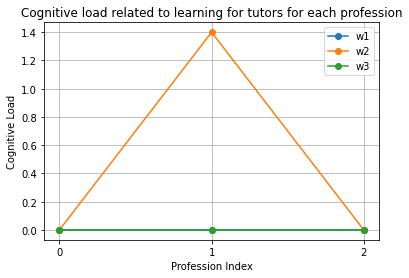

cognitive_load_apprentis=
[[0.  0.  0. ]
 [0.  0.  0. ]
 [0.  0.6 0. ]]


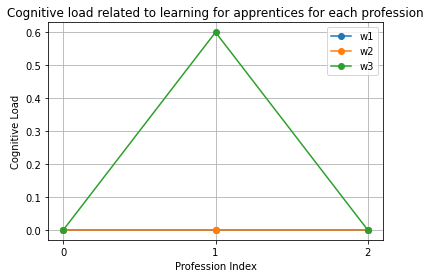

cognitive_load_collaboration=
[[0. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]]


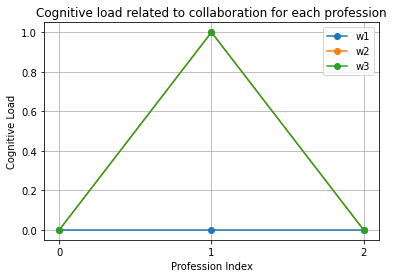

cognitive_load_total=
[[0.  0.  0. ]
 [0.  2.4 0. ]
 [0.  1.6 0. ]]


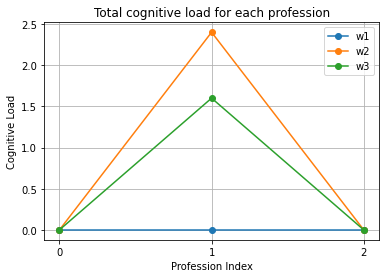

In [91]:
plot_cognitive_load_tutors(s_max_skills, instance, verbose=True)
plot_cognitive_load_apprentis(s_max_skills, instance, verbose=True)
plot_cognitive_load_collaboration(s_max_skills, instance, verbose=True)
plot_cognitive_load_total(s_max_skills, instance, verbose=True)

#### MIN MAKESPAN

In [92]:
s_min_makespan = model.solve(objective="three", weight=[1, 0, 0], priority=[1, 0, 2], verbose=False)
gantt_chart(s_min_makespan, instance, color=0, render="notebook")

Optimal solution found with objective value: 55.99999924292106


,Task,Start,Finish,Sub_operation,Operation,Job,mode,Level_worker,Difficulty_task,Elementary task,Metier
0,w1,18.100000,20.0,"(2,2,2)","(2,2)",J2,collaboratively,2.0,2,4.0,1.0
1,w2,0.100000,3.0,"(1,1,1)","(1,1)",J1,alone,4.0,1,0.0,0.0
2,w2,3.100000,13.0,"(2,2,1)","(2,2)",J2,alone,2.0,2,6.0,2.0
3,w2,13.100000,18.0,"(1,1,2)","(1,1)",J1,alone,3.0,3,2.0,1.0
4,w2,18.100000,20.0,"(2,2,2)","(2,2)",J2,collaboratively,3.0,2,4.0,1.0
5,w2,20.100000,22.0,"(2,2,3)","(2,2)",J2,collaboratively,3.0,2,4.0,1.0
6,w2,22.100000,32.0,"(1,1,3)","(1,1)",J1,alone,2.0,2,6.0,2.0
7,w2,32.100000,36.0,"(2,1,1)","(2,1)",J2,alone,3.0,3,3.0,1.0
8,w2,36.100000,51.0,"(2,1,2)","(2,1)",J2,alone,4.0,1,1.0,0.0
9,w2,51.099999,56.0,"(1,2,1)","(1,2)",J1,alone,3.0,3,2.0,1.0


cognitive_load_tutors=
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


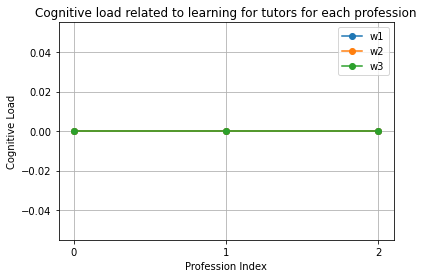

cognitive_load_apprentis=
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


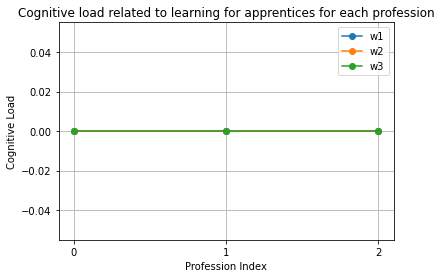

cognitive_load_collaboration=
[[0.  0.5 0. ]
 [0.  1.  0. ]
 [0.  0.5 0. ]]


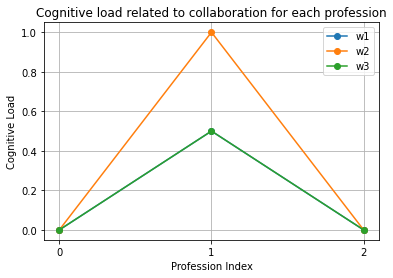

cognitive_load_total=
[[0.  0.5 0. ]
 [0.  1.  0. ]
 [0.  0.5 0. ]]


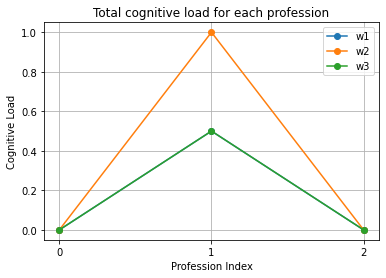

In [93]:
plot_cognitive_load_tutors(s_min_makespan, instance, verbose=True)
plot_cognitive_load_apprentis(s_min_makespan, instance, verbose=True)
plot_cognitive_load_collaboration(s_min_makespan, instance, verbose=True)
plot_cognitive_load_total(s_min_makespan, instance, verbose=True)

#### MIN CHARGE COGNITIVE

In [94]:
s_min_cognitive_load = model.solve(objective="three", weight=[0, 0, 1], priority=[1, 0, 0], verbose=False)
gantt_chart(s_min_cognitive_load, instance, color=0, render="notebook")

Optimal solution found with objective value: 62.0


,Task,Start,Finish,Sub_operation,Operation,Job,mode,Level_worker,Difficulty_task,Elementary task,Metier
0,w2,0.1,3.0,"(1,1,1)","(1,1)",J1,alone,4.0,1,0.0,0.0
1,w2,3.1,8.0,"(1,1,2)","(1,1)",J1,alone,3.0,3,2.0,1.0
2,w2,8.1,18.0,"(1,1,3)","(1,1)",J1,alone,2.0,2,6.0,2.0
3,w2,18.1,23.0,"(1,2,1)","(1,2)",J1,alone,3.0,3,2.0,1.0
4,w2,23.1,33.0,"(2,2,1)","(2,2)",J2,alone,2.0,2,6.0,2.0
5,w2,33.1,38.0,"(2,2,2)","(2,2)",J2,alone,3.0,2,4.0,1.0
6,w2,38.1,43.0,"(2,2,3)","(2,2)",J2,alone,3.0,2,4.0,1.0
7,w2,43.1,47.0,"(2,1,1)","(2,1)",J2,alone,3.0,3,3.0,1.0
8,w2,47.1,62.0,"(2,1,2)","(2,1)",J2,alone,4.0,1,1.0,0.0


cognitive_load_tutors=
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


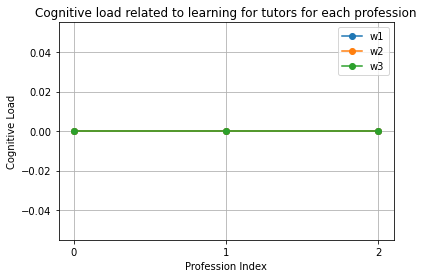

cognitive_load_apprentis=
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


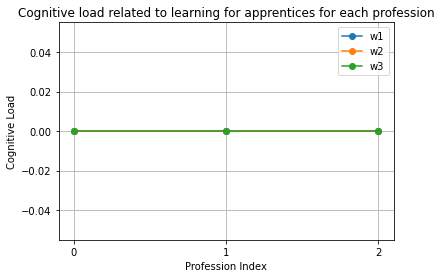

cognitive_load_collaboration=
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


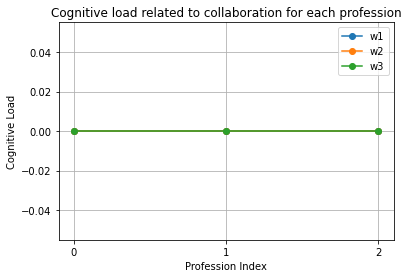

cognitive_load_total=
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


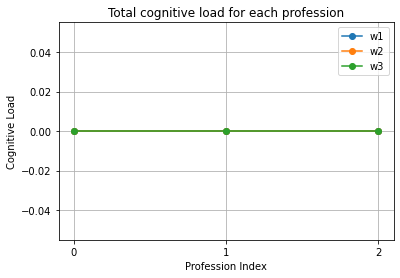

In [95]:
plot_cognitive_load_tutors(s_min_cognitive_load, instance, verbose=True)
plot_cognitive_load_apprentis(s_min_cognitive_load, instance, verbose=True)
plot_cognitive_load_collaboration(s_min_cognitive_load, instance, verbose=True)
plot_cognitive_load_total(s_min_cognitive_load, instance, verbose=True)

# Apres avoir optimisé chacun des objectifs, on peut comparer les 3 vecterus de solutions

In [96]:
s_max_skills.objective_values, s_min_makespan.objective_values, s_min_cognitive_load.objective_values

({0: 61.99999998180709, 1: -18.0, 2: 4.0},
 {0: 55.99999924292106, 1: -17.0, 2: 2.0},
 {0: 62.0, 1: -17.0, 2: 0.0})

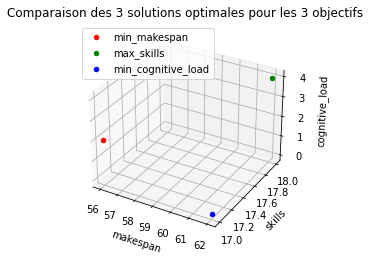

In [97]:

# %matplotlib qt
# from mpl_toolkits.mplot3d import proj3d

x = np.array([s_min_makespan.objective_values[0], s_max_skills.objective_values[0], s_min_cognitive_load.objective_values[0]])
y = np.array([- s_min_makespan.objective_values[1], - s_max_skills.objective_values[1], - s_min_cognitive_load.objective_values[1]])
z = np.array([s_min_makespan.objective_values[2], s_max_skills.objective_values[2], s_min_cognitive_load.objective_values[2]])

# Créer un objet Axes3D pour le graphique 3D
plt.figure("Exemple 3D")
axes = plt.axes(projection="3d")
axes.set_xlabel("makespan")
axes.set_ylabel("skills")
axes.set_zlabel("cognitive_load")


# On affiche notre nuage de points en 3D
axes.scatter(x[0], y[0], z[0], c="red", marker="o")
axes.scatter(x[1], y[1], z[1], c="green", marker="o")
axes.scatter(x[2], y[2], z[2], c="blue", marker="o")

axes.set_title("Comparaison des 3 solutions optimales pour les 3 objectifs")
axes.legend(["min_makespan", "max_skills", "min_cognitive_load"])
plt.show()

# ###Optimisation LEXICOGRAPHIQUE

### En suivant toutes les permutations possibles des 3 objectifs

In [98]:
s_L_S_M = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[0, 1, 2], verbose=False)
s_L_M_S = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[1, 0, 2], verbose=False)

s_S_L_M = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[0, 2, 1], verbose=False)
s_S_M_L = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[1, 2, 0], verbose=False)

s_M_L_S = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[2, 0, 1], verbose=False)
s_M_S_L = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[2, 1, 0], verbose=False)

Optimal solution found with objective value: 62.0
Optimal solution found with objective value: 62.006201
Optimal solution found with objective value: 84.99999999139948
Optimal solution found with objective value: 79.007901
Optimal solution found with objective value: 55.99997999997352
Optimal solution found with objective value: 55.99997999997352


In [102]:
sol = []
for i in (s_L_S_M, s_L_M_S, s_S_L_M, s_S_M_L, s_M_L_S, s_M_S_L):
    sol.append(i.objective_values)
print(sol)

[{0: 62.0, 1: -17.0, 2: 0.0}, {0: 62.006201, 1: -17.0, 2: 0.0}, {0: 84.99999999139948, 1: -19.0, 2: 3.9999999999999996}, {0: 79.007901, 1: -19.0, 2: 5.999999999999999}, {0: 55.99997999997352, 1: -17.0, 2: 2.0}, {0: 55.99997999997352, 1: -17.0, 2: 2.0}]


In [116]:
x = np.zeros((len(sol), 3))
for i in range(len(sol)):
    for j in range(3):
        x[i][j] = sol[i][j]
x

array([[ 62.        , -17.        ,   0.        ],
       [ 62.006201  , -17.        ,   0.        ],
       [ 84.99999999, -19.        ,   4.        ],
       [ 79.007901  , -19.        ,   6.        ],
       [ 55.99998   , -17.        ,   2.        ],
       [ 55.99998   , -17.        ,   2.        ]])

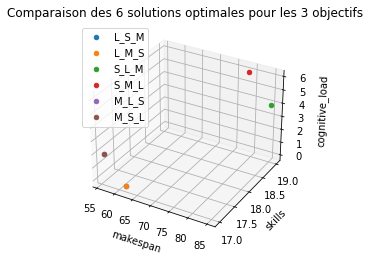

In [117]:
plt.figure("Exemple 3D")
axes = plt.axes(projection="3d")
axes.set_xlabel("makespan")
axes.set_ylabel("skills")
axes.set_zlabel("cognitive_load")

for i in range(len(x)):
    axes.scatter(x[i,0], - x[i,1], x[i,2], marker="o")


axes.set_title("Comparaison des 6 solutions optimales pour les 3 objectifs")
axes.legend(["L_S_M", "L_M_S", "S_L_M", "S_M_L", "M_L_S", "M_S_L"])
plt.show()

# ##Lancer le modèle avec differents jeux de poids aléatoires

In [142]:
NB_ITER = 50

sol = []

for i in range(NB_ITER):
    (x, y, z) = np.random.uniform(-1, 1, 3)
    s = model.solve(objective="three", weight=[x, y, z], priority=[0, 0, 0], verbose=False)
    if s is not None:
        for j in range(3):
            x = s.objective_values[0]
            y = - s.objective_values[1]
            z = s.objective_values[2]
        sol.append([x, y, z])

Optimal solution found with objective value: 55.99996141951658
Optimal solution found with objective value: 55.99999999767919
No optimal solution found. Status code: 4
No optimal solution found. Status code: 4
No optimal solution found. Status code: 4
No optimal solution found. Status code: 4
No optimal solution found. Status code: 4
Optimal solution found with objective value: 56.0
Optimal solution found with objective value: 56.0
No optimal solution found. Status code: 4
No optimal solution found. Status code: 4
Optimal solution found with objective value: 55.999999988370476
Optimal solution found with objective value: 61.99999558138286
Optimal solution found with objective value: 56.0
No optimal solution found. Status code: 4
Optimal solution found with objective value: 55.99999999449295
No optimal solution found. Status code: 4
Optimal solution found with objective value: 55.999999975534834
No optimal solution found. Status code: 4
No optimal solution found. Status code: 4
No optim

In [146]:
sol = np.array(sol)

In [147]:
sol

array([[55.99996142, 17.        ,  2.        ],
       [56.        , 17.        ,  2.        ],
       [56.        , 17.        ,  2.        ],
       [56.        , 17.        ,  2.        ],
       [55.99999999, 17.        ,  3.4       ],
       [61.99999558, 17.        ,  0.        ],
       [56.        , 17.        ,  3.4       ],
       [55.99999999, 17.        ,  3.4       ],
       [55.99999998, 17.        ,  2.        ],
       [56.        , 17.        ,  3.4       ],
       [95.        , 17.        ,  8.2       ],
       [55.99999484, 17.        ,  2.        ],
       [55.99999999, 17.        ,  3.4       ],
       [55.99999999, 17.        ,  2.        ],
       [55.99999999, 17.        ,  2.        ],
       [56.        , 17.        ,  2.        ],
       [55.9999924 , 17.        ,  2.        ],
       [55.99998611, 17.        ,  2.        ],
       [55.99999998, 17.        ,  3.4       ],
       [61.99998642, 18.        ,  5.4       ],
       [55.99999999, 17.        ,  3.4  

## 3d

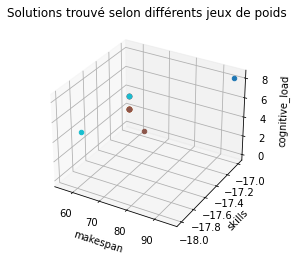

In [ ]:
plt.figure("Exemple 3D")
axes = plt.axes(projection="3d")
axes.set_xlabel("makespan")
axes.set_ylabel("skills")
axes.set_zlabel("cognitive_load")

for i in range(len(sol)):
    axes.scatter(sol[i,0], sol[i,1], sol[i,2], marker="o")


axes.set_title("Solutions trouvé selon différents jeux de poids")
plt.show()

## 2d

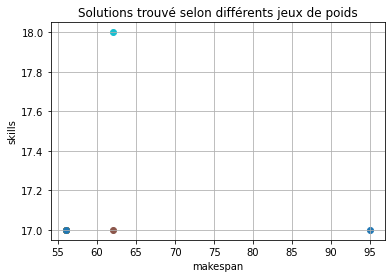

In [153]:
for i in range(len(sol)):
    plt.scatter(sol[i,0], sol[i,1], marker="o")
plt.xlabel("makespan")
plt.ylabel("skills")
plt.title("Solutions trouvé selon différents jeux de poids")
plt.grid()
plt.show()